In [49]:
!pip install xgboost lightgbm shap imbalanced-learn streamlit -q

## Global Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              ConfusionMatrixDisplay, silhouette_score, adjusted_rand_score, f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.pipeline import Pipeline

# Imbalanced
from imblearn.over_sampling import SMOTE

# Scipy
from scipy.cluster.hierarchy import dendrogram, linkage

# XGBoost / LightGBM
import xgboost as xgb
import lightgbm as lgb

# SHAP
import shap

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")


All libraries loaded successfully!
TensorFlow version: 2.20.0


---
## Preprocessing & Data Setup

### Pre-1: Load Data and Confirm Shape

In [2]:
# Column names for the Cleveland dataset
col_names = ['age','sex','cp','trestbps','chol','fbs','restecg',
             'thalach','exang','oldpeak','slope','ca','thal','target']

df_raw = pd.read_csv('processed.cleveland.data', header=None, names=col_names, na_values='?')

print("Shape:", df_raw.shape)
print("\nFirst 5 rows:")
display(df_raw.head())
print("\nData types:")
print(df_raw.dtypes)


Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


### Pre-2: Handle Missing Values

In [3]:
print("Missing values per column:")
print(df_raw.isnull().sum())

print("\nRows with at least one missing value:", df_raw.isnull().any(axis=1).sum())

df = df_raw.dropna()
print("\nRetained rows after dropping missing:", len(df))

# Binarise target: 0 = no disease, 1-4 = disease present -> 1
df['target'] = (df['target'] > 0).astype(int)
print("\nTarget distribution after binarising:")
print(df['target'].value_counts())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Rows with at least one missing value: 6

Retained rows after dropping missing: 297

Target distribution after binarising:
target
0    160
1    137
Name: count, dtype: int64


### Pre-3: Class Distribution & Imbalance Check

Class distribution:
        Count  Percent %
target                  
0         160      53.87
1         137      46.13


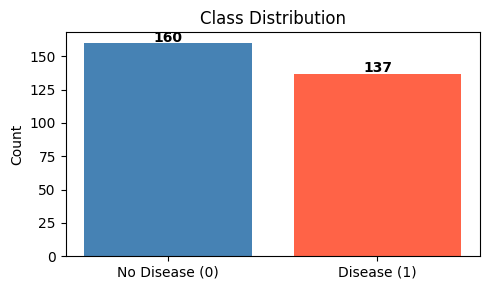

In [4]:
counts = df['target'].value_counts()
pct = df['target'].value_counts(normalize=True) * 100

print("Class distribution:")
print(pd.DataFrame({'Count': counts, 'Percent %': pct.round(2)}))

# Plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['steelblue','tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Conclusion: The dataset is relatively balanced (~45/55 split).
We will apply class_weight='balanced' in models instead of SMOTE, but we will apply SMOTE on the training split for the ANN to demonstrate it.

### Pre-4: Encoding and Scaling

In [5]:
# Separate features and target
X = df.drop('target', axis=1).copy()
y = df['target'].copy()

# Categorical columns to one-hot encode
cat_cols = ['cp', 'restecg', 'slope', 'thal']

# Continuous columns to standardise
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# One-hot encode (drop_first to avoid dummy trap)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print("Shape after one-hot encoding:", X_encoded.shape)
print("Columns:", list(X_encoded.columns))


Shape after one-hot encoding: (297, 22)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']


### Pre-5: Train/Test Split (80/20, stratified, random_state=42)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train class dist: {y_train.value_counts().to_dict()}")
print(f"Test  class dist: {y_test.value_counts().to_dict()}")

# Fit scaler on TRAIN only, apply to both
scaler = StandardScaler()
X_train[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test[cont_cols]  = scaler.transform(X_test[cont_cols])

print("\nScaling applied to continuous columns on train set only.")

# Also keep a standardised version of the raw numeric features for clustering
X_numeric = df[cont_cols + ['sex','fbs','exang']].copy()  # numeric subset for heatmap
X_std = StandardScaler().fit_transform(df.drop('target', axis=1))  # full std matrix for clustering


Train size: (237, 22), Test size: (60, 22)
Train class dist: {0: 128, 1: 109}
Test  class dist: {0: 32, 1: 28}

Scaling applied to continuous columns on train set only.


### Pre-6: Correlation Heatmap

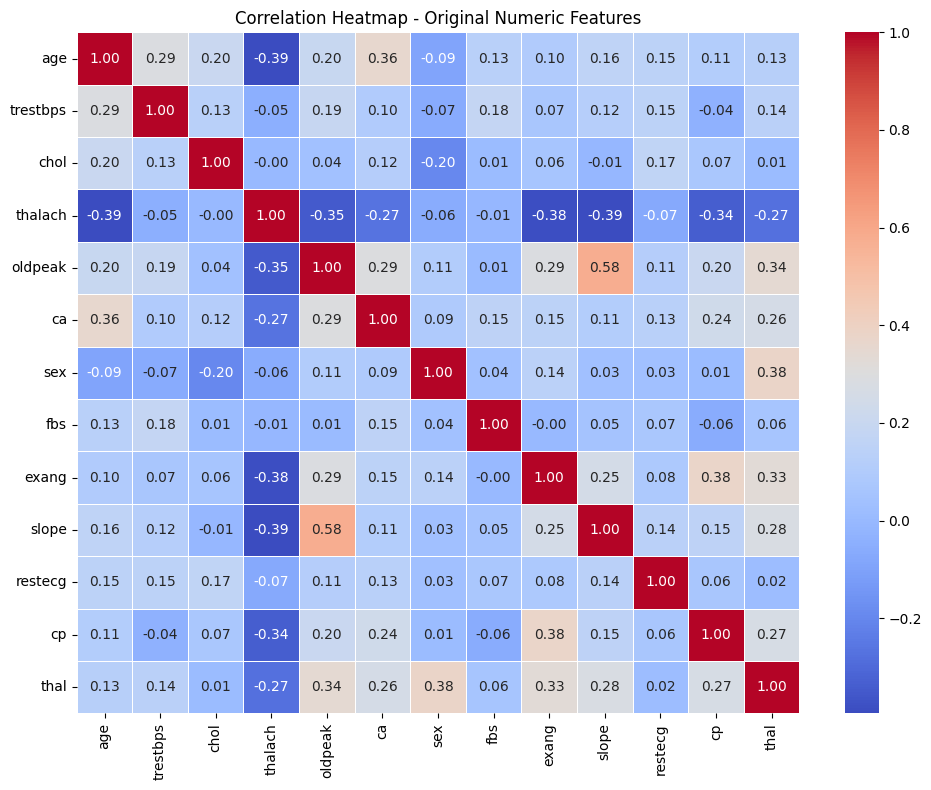

Top 3 strongest correlations:
  oldpeak ↔ slope: 0.579
  age ↔ thalach: 0.395
  thalach ↔ slope: 0.389


In [7]:
numeric_features = ['age','trestbps','chol','thalach','oldpeak','ca', 'sex','fbs','exang','slope','restecg','cp','thal']
corr = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Original Numeric Features')
plt.tight_layout()
plt.show()

# Top 3 strongest correlated pairs
import itertools
pairs = []
for c1, c2 in itertools.combinations(numeric_features, 2):
    pairs.append((c1, c2, abs(corr.loc[c1, c2])))
pairs.sort(key=lambda x: -x[2])

print("Top 3 strongest correlations:")
for c1, c2, v in pairs[:3]:
    print(f"  {c1} <-> {c2}: {v:.3f}")

Naive Bayes note: NB assumes feature independence.
High correlations (e.g., thalach <-> age) violate this assumption, which can hurt NB performance but won't cause errors.